# Toy manifold: train VP-SDE score net

1D manifold in R^2: `y = 0.6 sin(2x)` (same manifold as `preliminary/bahar_pushing.ipynb`, but here we actually train a
noise-prediction score net on a frozen set of atoms sampled along it, instead of using the closed-form drift).

Saves a checkpoint that `02_fr_guidance.ipynb` loads to run FR-guided sampling through `src/guidance/driver.py`.

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

ITERS_BY_REGIME = {"normal": 50000, "overtrained": 500000}   # overtrained = many more passes over the same
                                                            # fixed atoms, to induce memorization

config = {
    "regime": os.environ.get("REGIME", "normal"),   # picks both the checkpoint name
                          # (checkpoints/score_{regime}_N{N_data}.pt) and iters (ITERS_BY_REGIME above)
                          # -- changing N_data alone does NOT change the regime; iters is what actually
                          # controls overtraining/memorization
    "N_data": int(os.environ.get("N_DATA", 100)),
    "u_range": 3.2,
    "d": 2,
    "beta_min": 0.1, "beta_max": 20.0, "T": 1.0,
    "hidden": 128, "depth": 3, "batch": 256, "lr": 2e-4,
    "n_steps": 200,
    "seed": 0,
    "device": os.environ.get("DEVICE", "cpu"),
}
config["iters"] = ITERS_BY_REGIME[config["regime"]]
torch.manual_seed(config["seed"])
d, device = config["d"], config["device"]
print(f"d={d}, device={device}, regime={config['regime']}, N_data={config['N_data']}, iters={config['iters']}")

d=2, device=cpu, regime=overtrained, N_data=10, iters=500000


X_target: torch.Size([10, 2])


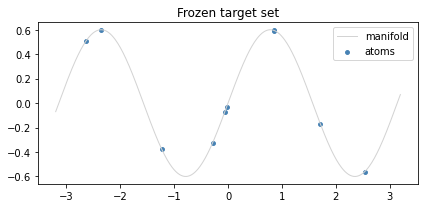

In [2]:
def manifold_from_u(u):
    return torch.stack([u, 0.6 * torch.sin(2 * u)], dim=-1)

u_target = (torch.rand(config["N_data"]) * 2 - 1) * config["u_range"]
X_target = manifold_from_u(u_target).to(device)
print(f"X_target: {X_target.shape}")

plt.figure(figsize=(6, 3))
u_curve = torch.linspace(-config["u_range"], config["u_range"], 400)
curve = manifold_from_u(u_curve)
plt.plot(curve[:, 0], curve[:, 1], color="lightgray", lw=1, label="manifold")
plt.scatter(X_target[:, 0].cpu(), X_target[:, 1].cpu(), s=15, color="steelblue", label="atoms")
plt.legend(); plt.title("Frozen target set"); plt.tight_layout(); plt.show()

In [3]:
def beta(t):
    return config["beta_min"] + t * (config["beta_max"] - config["beta_min"])

def alpha_bar(t):
    return torch.exp(-(config["beta_min"] * t + 0.5 * (config["beta_max"] - config["beta_min"]) * t ** 2))

def q_sample(x0, t):
    eps = torch.randn_like(x0)
    a = alpha_bar(t)[:, None]
    return a.sqrt() * x0 + (1 - a).sqrt() * eps, eps

In [4]:
class ScoreNet(nn.Module):
    def __init__(self, d, hidden, depth):
        super().__init__()
        self.input_proj = nn.Linear(d + 1, hidden)
        self.layers = nn.ModuleList([nn.Linear(hidden, hidden) for _ in range(depth * 2)])
        self.output_proj = nn.Linear(hidden, d)

    def forward(self, x, t):
        h = F.silu(self.input_proj(torch.cat([x, t[:, None]], dim=-1)))
        for i in range(0, len(self.layers), 2):
            r = F.silu(self.layers[i](h))
            r = self.layers[i + 1](r)
            h = h + r
        return self.output_proj(h)

net = ScoreNet(d, config["hidden"], config["depth"]).to(device)
print(f"Parameters: {sum(p.numel() for p in net.parameters()):,}")

def loss_fn(net, x0):
    t = torch.rand(x0.shape[0], device=x0.device).clamp(min=1e-3) * config["T"]
    xt, eps = q_sample(x0, t)
    return ((net(xt, t) - eps) ** 2).mean()

Parameters: 99,842


iter      0  loss=1.2994
iter  25000  loss=0.1757
iter  50000  loss=0.1643
iter  75000  loss=0.1193
iter 100000  loss=0.1596
iter 125000  loss=0.1292
iter 150000  loss=0.1300
iter 175000  loss=0.1545
iter 200000  loss=0.1369
iter 225000  loss=0.1763
iter 250000  loss=0.1717
iter 275000  loss=0.1426
iter 300000  loss=0.1816
iter 325000  loss=0.1473
iter 350000  loss=0.1673
iter 375000  loss=0.1834
iter 400000  loss=0.1583
iter 425000  loss=0.1918
iter 450000  loss=0.1765
iter 475000  loss=0.1414
Training done.


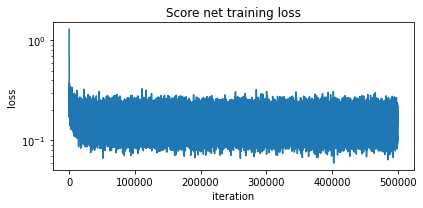

In [5]:
opt = torch.optim.Adam(net.parameters(), lr=config["lr"])
losses = []
print_every = max(1, config["iters"] // 20)
for i in range(config["iters"]):
    idx = torch.randint(0, config["N_data"], (config["batch"],))
    loss = loss_fn(net, X_target[idx])
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())
    if i % print_every == 0:
        print(f"iter {i:6d}  loss={loss.item():.4f}")
net.eval()
print("Training done.")

plt.figure(figsize=(6, 3))
plt.semilogy(losses)
plt.xlabel("iteration"); plt.ylabel("loss"); plt.title("Score net training loss")
plt.tight_layout(); plt.show()

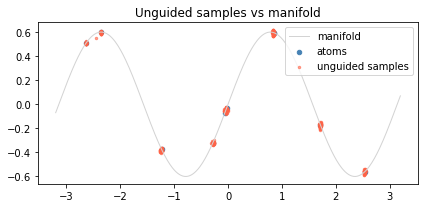

In [6]:
def sample(B, n_steps=None):
    n_steps = n_steps or config["n_steps"]
    x = torch.randn(B, d, device=device)
    dt = config["T"] / n_steps
    for k in reversed(range(n_steps)):
        t = torch.full((B,), (k + 1) * dt, device=device)
        eps_hat = net(x, t)
        score = -eps_hat / (1 - alpha_bar(t))[:, None].sqrt()
        drift = -0.5 * beta(t)[:, None] * x - beta(t)[:, None] * score
        noise = beta(t)[:, None].sqrt() * torch.randn_like(x) if k > 0 else 0
        x = x - drift * dt + noise * dt ** 0.5
    return x.detach()

with torch.no_grad():
    X_gen = sample(300)

plt.figure(figsize=(6, 3))
plt.plot(curve[:, 0], curve[:, 1], color="lightgray", lw=1, label="manifold")
plt.scatter(X_target[:, 0].cpu(), X_target[:, 1].cpu(), s=20, color="steelblue", label="atoms")
plt.scatter(X_gen[:, 0].cpu(), X_gen[:, 1].cpu(), s=6, color="tomato", alpha=0.6, label="unguided samples")
plt.legend(); plt.title("Unguided samples vs manifold"); plt.tight_layout(); plt.show()

In [7]:
os.makedirs("checkpoints", exist_ok=True)
ckpt_path = f"checkpoints/score_{config['regime']}_N{config['N_data']}.pt"
torch.save({
    "net_state": net.state_dict(),
    "X_target": X_target.cpu(),
    "u_target": u_target.cpu(),
    "config": config,
}, ckpt_path)
print(f"Saved {ckpt_path}")

Saved checkpoints/score_overtrained_N10.pt
